# Module 2: Epidemic Modeling Template

## Team Members:
* Dane Wleklinski
* Molly Janousek

## Project Title: Characterizing an Unkown Viral Illness


## Project Goal:
This project seeks to: estimate the initial growth rate from outbreak data, predict the spread of the disease, find when cases will peak, determine the virus family, and provide the best intervention strategy to reduce the spread of illness.

## 1. Data and disease background
You can fill out this section throughout the module as you uncover more information about the mystery disease.

By the end of the module (when submitting), you should have some information about each of the following points:
* Prevalence & incidence in the UVA population
* Economic burden (you can generalize from respiratory viruses)
* Symptoms
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology - you can generalize from viral biology)


## 2. Data Analysis
This section should be filled out sequentially as a full report of the work you've done over this module. You can copy and paste code from any main.py file here, and run it to produce plots. Once you gain more information throughout the module, you do not need to go back and "fix" earlier results. In other words, if your early predictions are found to be wrong when gaining new data, do not go back and rewrite them.

### __Initial Analysis Questions:__
##### What do you notice about the initial infections?
The initial infections increase over time. The rate of increase accelerates, so the virus is spreading faster and faster. The curve is exponential.
##### How could we measure how quickly its spreading?
We could measure the rate of increase in the number of active cases over time. This can be done by calculating the growth rate, which is the percentage increase in active cases from one day to the next.
##### What information about the virus would be helpful in determining the shape of the outbreak curve?
Information about the virus's transmission rate, incubation period, and recovery time would be helpful in determining the shape of the outbreak curve.

### __Questions About Estimated R0:__

##### What viruses have a similar R0? Use the viruses.html file to find a virus or 2 with a similar R0 and give a 1-2 sentence background of the diseases.

The estimated R0 for the mystery virus is 1.24, which is similar to the R0 of seasonal influenza (R0 of 1.3). 
Seasonal influenza is a contagious respiratory illness caused by influenza viruses, which can lead to mild to severe illness and can sometimes result in death,
particularly in vulnerable populations such as the elderly and those with underlying health conditions.

This R0 is also similar to the R0 of Rhinovirus (R0 of 1.5).
Rhinovirus is a common viral infectious agent that primarily causes the common cold. 
It is highly contagious and can lead to symptoms such as a runny nose, sore throat, cough, and congestion. Rhinovirus infections are typically mild and self-limiting,
but they can cause complications in individuals with weakened immune systems or pre-existing respiratory conditions.

##### How accurate do you think your R0 estimate is?
The R0 estimate is based on the early exponential growth phase of the outbreak, which can be influenced by various factors such as underreporting of cases, changes in testing rates, and public health interventions. Therefore, while the estimate provides a useful measure of transmissibility, it may not be perfectly accurate and should be interpreted with caution.

### 2a. Methods

*IN A SUMMARY, DESCRIBE THE METHODS YOU USED TO ANALYZE AND MODEL THE DATA.*


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)

This code loads the mystery virus data from the first data release and plots the daily active cases over time to visualize the initial spread. Then, we fit an exponential growth model to the data to estimate the R0 value, assuming an average infectious period of 2 days. We printed the R0, and display two plots to show the data points with the fitted exponential curve.

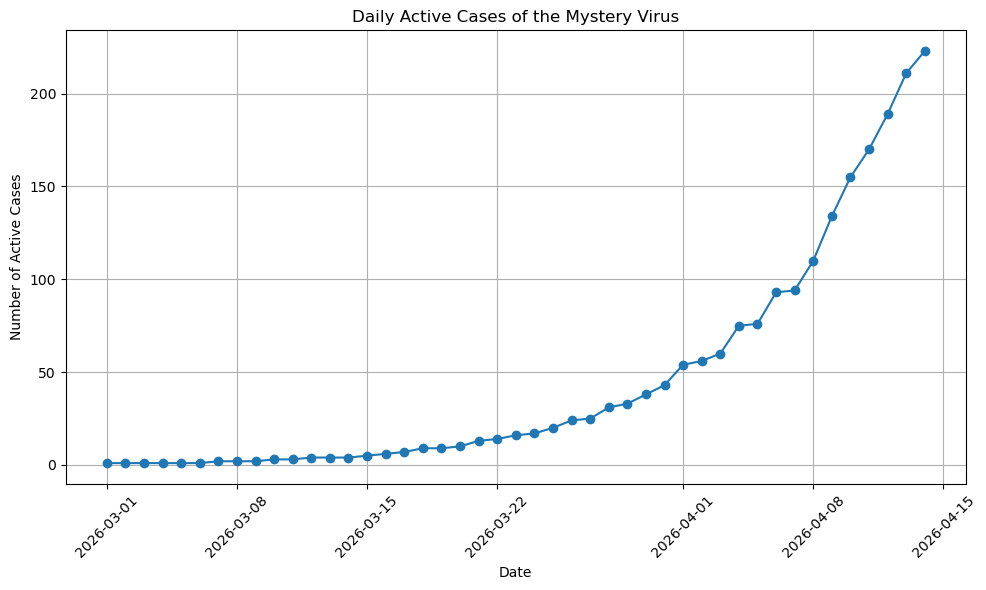

Estimated R0: 1.24


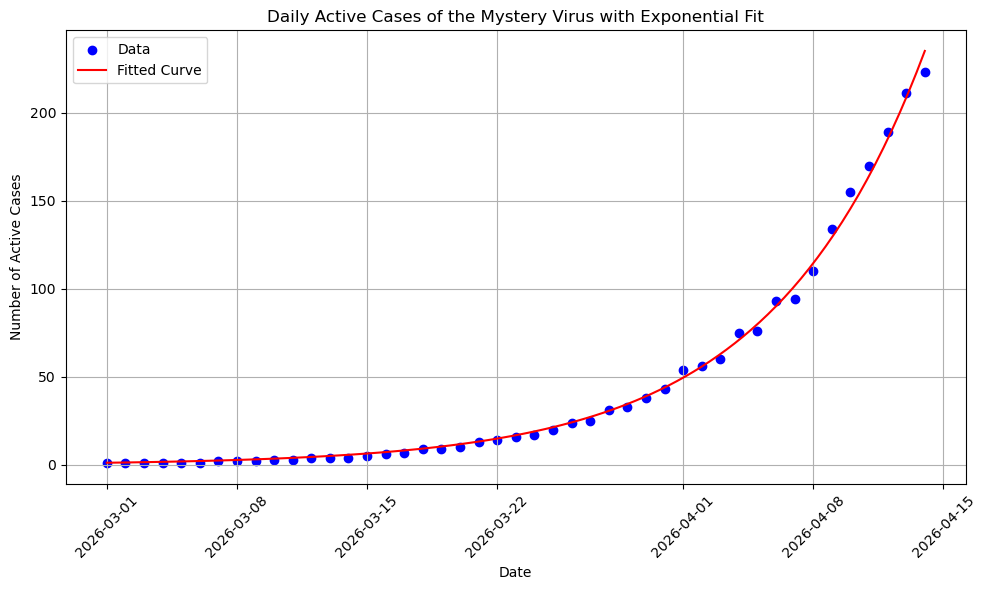

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np

# Load the data
data = pd.read_csv("../Data/mystery_virus_daily_active_counts_RELEASE#1.csv", parse_dates=['date'], header=0, index_col=None)

# Make a plot of the active cases over time
plt.figure(figsize=(10, 6))
plt.plot(data['date'], data['active reported daily cases'], marker='o', linestyle='-')
plt.title('Daily Active Cases of the Mystery Virus')
plt.xlabel('Date')
plt.ylabel('Number of Active Cases') 
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

# Define the exponential growth function
def exponential_growth(t, I0, r):
    return I0 * np.exp(r * t)

# Prepare the data for fitting
data['days'] = (data['date'] - data['date'].min()).dt.days

# Fit the exponential growth model to the data
popt, pcov = curve_fit(exponential_growth, data['days'], data['active reported daily cases'], p0=(1, 0.1))
I0, r = popt
R0 = 1 + r * 2  # average infectious period of 2 days
print(f"Estimated R0: {R0:.2f}")

# Plot the data and the fitted curve
plt.figure(figsize=(10, 6))
plt.scatter(data['date'], data['active reported daily cases'], label='Data', color='blue')
t_fit = np.linspace(0, data['days'].max(), 100)
plt.plot(data['date'].min() + pd.to_timedelta(t_fit, unit='D'), exponential_growth(t_fit, *popt), label='Fitted Curve', color='red')
plt.title('Daily Active Cases of the Mystery Virus with Exponential Fit')
plt.xlabel('Date')
plt.ylabel('Number of Active Cases')
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

*Summary of Analysis After Data Release #1:* The data revealed exponential growth in active cases over the initial period. Fitting an exponential model to the early data estimated R0 at 1.24, indicating moderate transmissibility comparable to seasonal influenza or rhinovirus. This R0 estimate provides a baseline for understanding the virus's ability to spread through populations.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>

### 2c. Use Euler's method to solve the SEIR model.

This code defines the SEIR (Susceptible-Exposed-Infected-Recovered) model differential equations and uses Euler's method for numerical integration. It loads the data from the second data release, sets initial conditions, and simulates the SEIR model using example parameter values (beta=0.3, sigma=0.2, gamma=0.1). The resulting plot shows Susceptible, Exposed, Infected, and Recovered populations over the observed period.

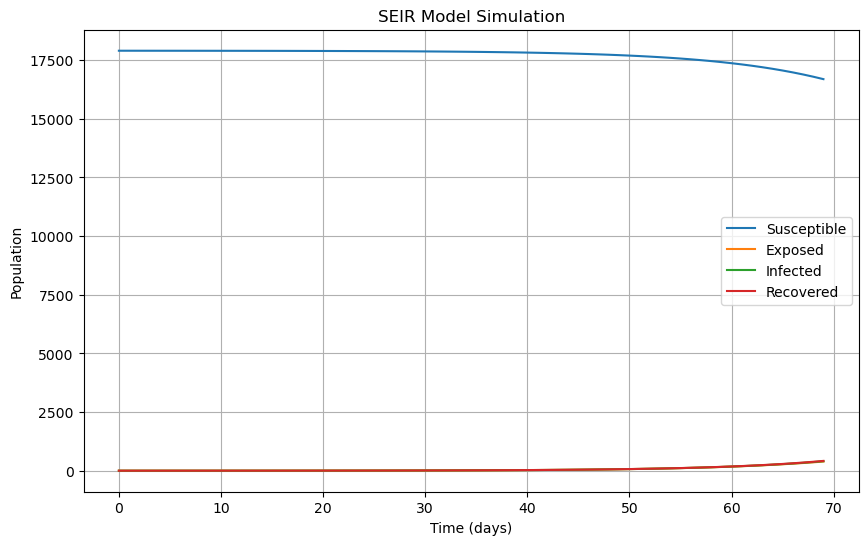

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the data for RELEASE#2
data = pd.read_csv("../Data/mystery_virus_daily_active_counts_RELEASE#2.csv", parse_dates=['date'], header=0, index_col=None)
observed_data = data["active reported daily cases"].values
num_days = len(observed_data)
timepoints = np.arange(num_days)

# SEIR differential equations
def seir_model(y, t, beta, sigma, gamma, N):
    S, E, I, R = y
    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - sigma * E
    dIdt = sigma * E - gamma * I
    dRdt = gamma * I
    return dSdt, dEdt, dIdt, dRdt

# Euler method implementation
def euler_method(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N):
    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))
    # Initial conditions
    S[0], E[0], I[0], R[0] = S0, E0, I0, R0
    # Euler integration
    for i in range(1, len(timepoints)):
        dt = timepoints[i] - timepoints[i-1]
        dSdt, dEdt, dIdt, dRdt = seir_model(
            (S[i-1], E[i-1], I[i-1], R[i-1]),
            timepoints[i-1],
            beta, sigma, gamma, N
        )
        # Update values using Euler's method
        S[i] = S[i-1] + dSdt * dt
        E[i] = E[i-1] + dEdt * dt
        I[i] = I[i-1] + dIdt * dt
        R[i] = R[i-1] + dRdt * dt
    # return results
    return S, E, I, R

# Initial conditions
S0 = 17900
E0 = 0
I0 = 1
R0 = 1.24  # estimated from data (day 1 data R0 value)
N = S0 + E0 + I0 + R0

# Example parameters (will be fitted later)
beta = 0.3
sigma = 0.2
gamma = 0.1

# Solve the SEIR model
S, E, I, R = euler_method(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N)

# Plot the SEIR model results
plt.figure(figsize=(10, 6))
plt.plot(timepoints, S, label='Susceptible')
plt.plot(timepoints, E, label='Exposed')
plt.plot(timepoints, I, label='Infected')
plt.plot(timepoints, R, label='Recovered')
plt.title('SEIR Model Simulation')
plt.xlabel('Time (days)')
plt.ylabel('Population')
plt.legend()
plt.grid()
plt.show()


Calculate the estimated peak and active cases 

In [2]:
peak_index = np.argmax(I)
peak_day = timepoints[peak_index]
peak_cases = I[peak_index]
print(f"Peak occurs on day {peak_day} with {peak_cases:.0f} active cases.")

Peak occurs on day 69 with 404 active cases.


### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.

This code performs a grid search over ranges of beta, gamma, and sigma parameters to find the combination of values that minimizes the sum of squared errors (SSE) between the model's predicted infected population and the observed data. It uses our Euler method and SEIR model. The best-fitting parameters and the corresponding SSE are printed. These are the optimized values for the transmission rate (beta), incubation rate (sigma), and recovery rate (gamma).

In [3]:
# Grid search for parameter estimation
def grid_search_parameters(timepoints, N,
                           S0, E0, I0, R0,
                           observed_data,
                           beta_range=None,
                           sigma_range=None,
                           gamma_range=None):
    # Define default parameter ranges if not provided
    if beta_range is None:
        beta_range = np.linspace(0.1, 1.0, 10)
    if sigma_range is None:
        sigma_range = np.linspace(0.1, 1.0, 10)
    if gamma_range is None:
        gamma_range = np.linspace(0.1, 1.0, 10)
    # Initialize array to store SSE values for each parameter combination
    sse_array = np.zeros((len(beta_range),
                          len(sigma_range),
                          len(gamma_range)))
    # Loop through all combinations of parameters and compute SSE
    for b, beta in enumerate(beta_range):
        for s, sigma in enumerate(sigma_range):
            for g, gamma in enumerate(gamma_range):
                S, E, I, R = euler_method(beta, sigma, gamma,
                                          S0, E0, I0, R0,
                                          timepoints, N)
                sse_array[b, s, g] = np.sum((I - observed_data) ** 2)
    # Find the parameter combination with the lowest SSE
    min_index = np.unravel_index(np.argmin(sse_array), sse_array.shape)
    best_beta = beta_range[min_index[0]]
    best_sigma = sigma_range[min_index[1]]
    best_gamma = gamma_range[min_index[2]]
    best_sse = sse_array[min_index]
    # return best parameters and SSE
    return best_beta, best_sigma, best_gamma, best_sse

# Perform grid search using the observed data to find the best parameters
best_beta, best_sigma, best_gamma, best_sse = grid_search_parameters(
    timepoints, N, S0, E0, I0, R0, observed_data
)

# Print best parameters and SSE
print(f"Best parameters: beta={best_beta}, sigma={best_sigma}, gamma={best_gamma}, SSE={best_sse}")

Best parameters: beta=0.6, sigma=0.2, gamma=0.2, SSE=127284.81053177129


### 2e. Plot the model-predicted infections over time compared to the data.

This code uses the best-fit parameters from the grid search to simulate the SEIR model and plot the results with the observed infected data. The plot compares the model's predicted Susceptible, Exposed, Infected, and Recovered curves with the actual reported active cases (shown as red scatter points), demonstrating how well the model fits the data.

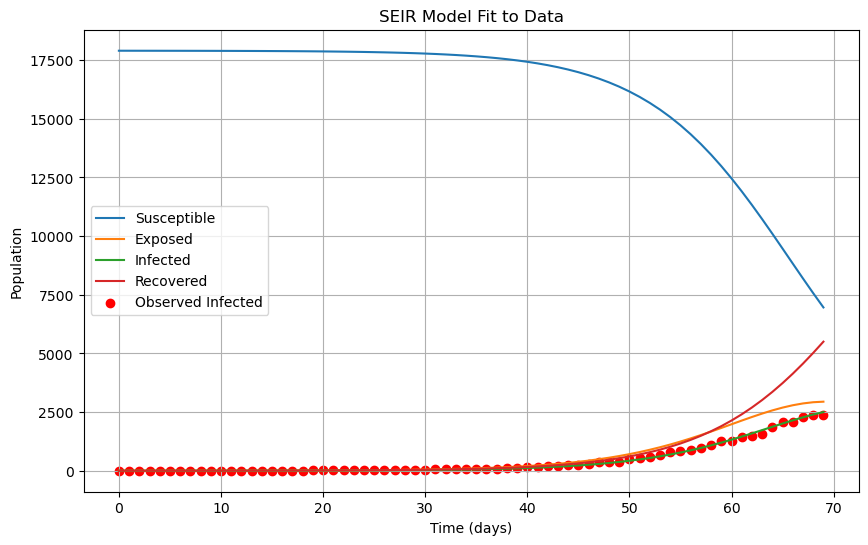

In [4]:
# Plot best-fit model
S, E, I, R = euler_method(best_beta, best_sigma, best_gamma, S0, E0, I0, R0, timepoints, N) #using previously found best parameters to solve the SEIR model again for plotting

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(timepoints, S, label='Susceptible')
plt.plot(timepoints, E, label='Exposed')
plt.plot(timepoints, I, label='Infected')
plt.plot(timepoints, R, label='Recovered')
plt.scatter(timepoints, observed_data, color='red', label='Observed Infected')
plt.title('SEIR Model Fit to Data')
plt.xlabel('Time (days)')
plt.ylabel('Population')
plt.legend()
plt.grid()
plt.show()

### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.

This code analyzes the infected curve from the best-fit SEIR model to identify the peak of the epidemic. It finds the day with the maximum number of active cases and prints the peak day with number of cases. This tells us when the outbreak is expected to reach its highest point.

In [5]:
# Predict the peak
peak_index = np.argmax(I)
peak_day = timepoints[peak_index]
peak_cases = I[peak_index]
print(f"Peak occurs on day {peak_day} with {peak_cases:.0f} active cases.")

Peak occurs on day 69 with 2500 active cases.


*Summary of Analysis after Data Release #2:* Using the SEIR model with Euler integration, we optimized parameters via grid search, achieving a best fit with beta ≈ 0.6, sigma ≈ 0.2, gamma ≈ 0.2, and minimal SSE. The model predicted the epidemic peak at day 69 with about 2500 active cases. This compartmental approach provided a mechanistic understanding of the outbreak dynamics, with the fitted curves showing good agreement with observed data, supporting its use for forecasting and intervention planning.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2f. Plot the full dataset (Data Release #3) against your model.
This section should come from your python code after Data Release #3.


### 2g. Intervention strategies for new outbreak at VT (70 days of infection)
This section should come from your python code after Data Release #3.



## Verify and validate your analysis: 

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

### Error Calculation 
* Estimated value peak at day 69 with 404 cases

* Predicted value with found values peak at day 69 with 2500 cases

* Error for peak days was 0 (69-69/69)

* Error for peak number of cases was 83.84% (2500-404/2500)


### Discussion Of Model Limitations 
* Our Beta, Sigma, and Gamma values for our first predicted SEIR were 0.3, 0.2, and 0.1

* Then we used Eulers and SEIR Model to find the best fitted values for Beta, Sigma, and Gamma and found them to be: 0.6, 0.2, and 0.2

* Although we predicted the sigma value correctly, the Beta and Gamma values were incorrect leading to a high error in our peak cases